# 引用套件

In [11]:
import os    # 匯入必要套件：檔案處理、影像處理與數值運算",
import glob    # OpenCV 用於影像讀寫與處理",
import cv2    # numpy 用於陣列與數值計算",
import numpy as np    # skimage.morphology 提供 remove_small_objects / holes 等形態學工具",
from skimage import morphology    # matplotlib 用於顯示結果",
from matplotlib import pyplot as plt    # pathlib 提供跨平台路徑處理",
from pathlib import Path

# 定義函式

In [12]:
def detect_defects_gray(gray, debug=False, background_kernel=101, alpha=1.25, min_size=1000, opening_size=5):
    """偵測單張灰階影像的瑕疵（中文註解版）。
    參數說明：
      gray: uint8 灰階影像
      debug: 若為 True，回傳中間步驟影像 (out_mask, thresh, corrected, low_contrast)
      background_kernel: 用於估計背景/照明的 Gaussian 權值大小（奇數）
      alpha: 對比度縮放係數（小於 1 會降低對比）
      min_size: 最小連通元件尺寸（像素），小於此值會被視為雜訊移除
      opening_size: 形態學開運算 kernel 大小，用以移除小斑點
    回傳：
      out_mask: uint8 二值遮罩（瑕疵=0，非瑕疵=255），或 debug 時回傳 tuple
    """
    # 1) 照明校正：用大核的 Gaussian 平滑估計背景，再從原圖減去背景
    img = gray.astype(np.float32)
    k = int(background_kernel)
    if k % 2 == 0:
        k += 1  # kernel 必須為奇數
    background = cv2.GaussianBlur(img, (k, k), 0)
    corrected = cv2.subtract(img, background)
    # 將校正後影像正規化回 0-255
    corrected = cv2.normalize(corrected, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 2) 降低對比度以降低紋理敏感度
    low_contrast = cv2.convertScaleAbs(corrected, alpha=float(alpha), beta=0)

    # 3) 去雜訊後做二值化（Otsu）
    blur = cv2.GaussianBlur(low_contrast, (7, 7), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 4) 假設瑕疵通常較暗，將 th==0 視為瑕疵 -> 建立 boolean mask (True = defect)
    mask_defect_bool = (th == 0)

    # 5) 開運算移除孤立小斑點（雜訊）
    if opening_size and opening_size > 1:
        op_k = int(opening_size)
        if op_k % 2 == 0:
            op_k += 1
        ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (op_k, op_k))
        # morphologyEx 要求 uint8，使用 0/1 再轉回 boolean
        temp = cv2.morphologyEx(mask_defect_bool.astype('uint8'), cv2.MORPH_OPEN, ker)
        mask_defect_bool = temp.astype(bool)

    # 6) 移除小連通元件與填補小洞（skimage 接受 boolean mask）
    # 確保傳入的是 boolean ndarray
    mask_defect_bool = morphology.remove_small_objects(mask_defect_bool, min_size=min_size)
    mask_defect_bool = morphology.remove_small_holes(mask_defect_bool, area_threshold=min_size)

    # 7) 轉回 0/255 格式（我們約定瑕疵=0，非瑕疵=255）
    # mask_defect_bool == True 表示瑕疵，輸出瑕疵為 0，非瑕疵為 255
    out_mask = np.where(mask_defect_bool, 0, 255).astype(np.uint8)

    if debug:
        # 回傳中間資訊供除錯：預測遮罩、二值化結果、校正後影像、降對比影像
        return out_mask, th, corrected, low_contrast
    return out_mask

def save_mask_png(mask, out_path):
    # mask already in 0/255 with defects=0, non-defect=255
    cv2.imwrite(str(out_path), mask)

def compute_metrics(gt_mask, pred_mask):
    # gt_mask and pred_mask: 0 for defect, 255 for non-defect
    gt_bin = (gt_mask == 0).astype(np.uint8)
    pr_bin = (pred_mask == 0).astype(np.uint8)
    tp = int(np.logical_and(gt_bin==1, pr_bin==1).sum())
    tn = int(np.logical_and(gt_bin==0, pr_bin==0).sum())
    fp = int(np.logical_and(gt_bin==0, pr_bin==1).sum())
    fn = int(np.logical_and(gt_bin==1, pr_bin==0).sum())
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp+tn+fp+fn)>0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "tp": tp,
            "tn": tn,
            "fp": fp,
            "fn": fn
        }

def postprocess_mask(pred_mask, dilation_size=5):
    """Apply morphological dilation to the defect mask to better match GT.
    pred_mask: uint8 mask with defects=0, non-defect=255
    dilation_size: radius/size of dilation kernel (int)
    Returns: uint8 mask with defects=0, non-defect=255 after dilation
    """
    # Convert to binary where defect=1
    bin_def = (pred_mask == 0).astype('uint8') * 255
    if dilation_size and dilation_size > 0:
        k = int(dilation_size)
        # use elliptical kernel
        ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        dilated = cv2.dilate(bin_def, ker, iterations=1)
    else:
        dilated = bin_def
    # convert back to 0 (defect) / 255 (non-defect)
    out = np.where(dilated == 255, 0, 255).astype(np.uint8)
    return out

# 中文說明：
# postprocess_mask 用於對預測遮罩做形態學膨脹，目的是讓預測區域能更接近標準答案（GT）。
# 參數 dilation_size 可調整膨脹程度；若你想更保守（避免擴散過多誤檢），可降低此值。

# 測試每一步

C:\Users\user\AppData\Local\Temp\ipykernel_14888\2518822326.py:95: UserWarning: Glyph 27161 (\N{CJK UNIFIED IDEOGRAPH-6A19}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_14888\2518822326.py:95: UserWarning: Glyph 28310 (\N{CJK UNIFIED IDEOGRAPH-6E96}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_14888\2518822326.py:95: UserWarning: Glyph 31572 (\N{CJK UNIFIED IDEOGRAPH-7B54}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_14888\2518822326.py:95: UserWarning: Glyph 26696 (\N{CJK UNIFIED IDEOGRAPH-6848}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_14888\2518822326.py:95: UserWarning: Glyph 28961 (\N{CJK UNIFIED IDEOGRAPH-7121}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_14888\2518822326.py:95: UserWarning: Glyph 27284 (\N{CJK 

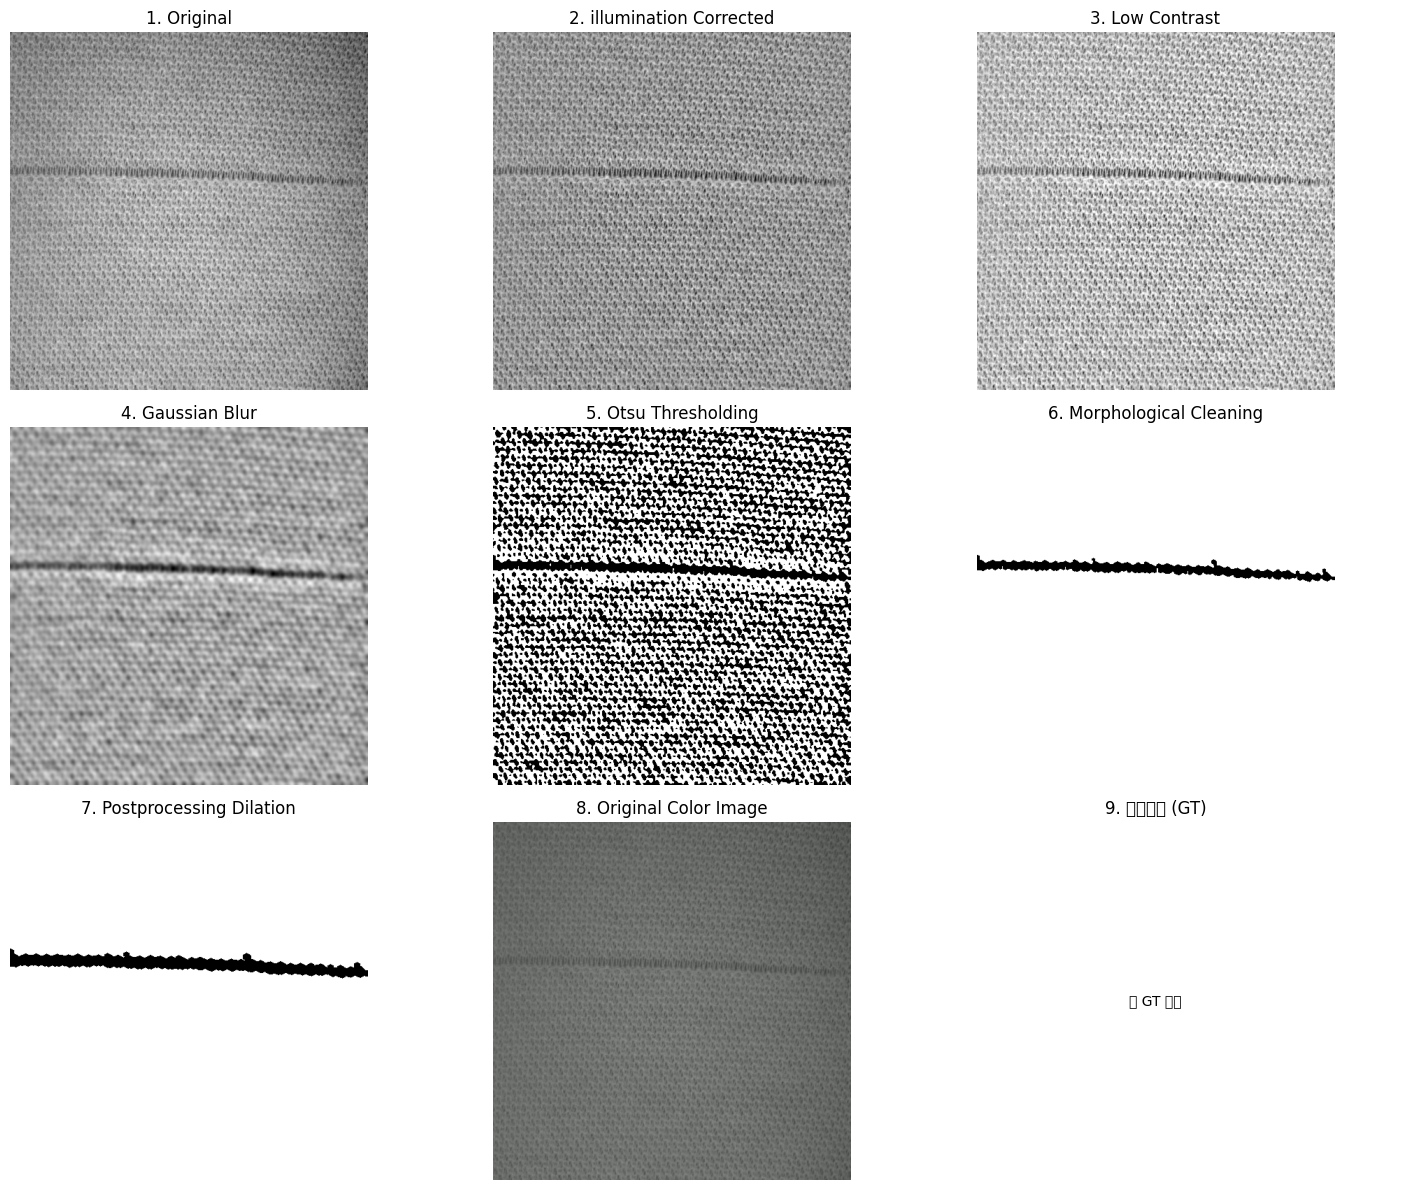

In [13]:
# 測試影像處理的每個步驟（中間結果可視化）
from pathlib import Path

# 讀取第一張測試影像
test_image_path = Path('new test images') / 'image4.png'
if test_image_path.exists():
    test_img = cv2.imread(str(test_image_path))
    gray = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)
    
    # 呼叫 detect_defects_gray 的 debug 模式取得中間步驟
    out_mask, th, corrected, low_contrast = detect_defects_gray(
        gray, debug=True,
        background_kernel=101,
        alpha=1.25,
        min_size=750,
        # opening_size=5
    )
    
    # 計算後處理（膨脹）的結果
    pred_pp = postprocess_mask(out_mask, dilation_size=5)
    
    # 佈局展示每個處理步驟（3 行 3 列，共 9 個步驟）
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    # 第 1 行：原始影像、照明校正、降對比
    axes[0, 0].imshow(gray, cmap='gray')
    axes[0, 0].set_title('1. Original')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(corrected, cmap='gray')
    axes[0, 1].set_title('2. illumination Corrected')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(low_contrast, cmap='gray')
    axes[0, 2].set_title('3. Low Contrast')
    axes[0, 2].axis('off')
    
    # 第 2 行：模糊、Otsu 二值化、瑕疵二值遮罩
    blur = cv2.GaussianBlur(low_contrast, (15, 15), 0)
    axes[1, 0].imshow(blur, cmap='gray')
    axes[1, 0].set_title('4. Gaussian Blur')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(th, cmap='gray')
    axes[1, 1].set_title('5. Otsu Thresholding')
    axes[1, 1].axis('off')
    
    # 瑕疵遮罩（瑕疵=黑色，非瑕疵=白色）
    mask_before_postproc = out_mask
    axes[1, 2].imshow(mask_before_postproc, cmap='gray')
    axes[1, 2].set_title('6. Morphological Cleaning')
    axes[1, 2].axis('off')
    
    # 第 3 行：膨脹後處理、最終結果、GT 對比
    axes[2, 0].imshow(pred_pp, cmap='gray')
    axes[2, 0].set_title('7. Postprocessing Dilation')
    axes[2, 0].axis('off')
    
    # 顯示原始彩色影像
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    axes[2, 1].imshow(test_img_rgb)
    axes[2, 1].set_title('8. Original Color Image')
    axes[2, 1].axis('off')
    
    # 嘗試讀取並顯示 GT
    gt_paths = [
        Path('texture test images') / 'image1_gt.png',
        Path('texture test images') / 'image1_ans.png',
        Path('texture test images') / 'GT.png'
    ]
    gt_found = None
    for gp in gt_paths:
        if gp.exists():
            gt_found = cv2.imread(str(gp), cv2.IMREAD_GRAYSCALE)
            break
    
    if gt_found is not None:
        axes[2, 2].imshow(gt_found, cmap='gray')
        axes[2, 2].set_title('9. 標準答案 (GT)')
        axes[2, 2].axis('off')
        
        # 計算並顯示評估指標
        _, gt_bin = cv2.threshold(gt_found, 128, 255, cv2.THRESH_BINARY)
        metrics = compute_metrics(gt_bin, pred_pp)
        print('\n=== 偵測結果評估 ===')
        print(f'Accuracy:  {metrics["accuracy"]:.4f}')
        print(f'Precision: {metrics["precision"]:.4f}')
        print(f'Recall:    {metrics["recall"]:.4f}')
        print(f'TP={metrics["tp"]}, TN={metrics["tn"]}, FP={metrics["fp"]}, FN={metrics["fn"]}')
    else:
        axes[2, 2].text(0.5, 0.5, '無 GT 檔案', ha='center', va='center')
        axes[2, 2].set_title('9. 標準答案 (GT)')
        axes[2, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print('找不到測試影像:', test_image_path)

Processing image1.png ...


C:\Users\user\AppData\Local\Temp\ipykernel_14888\4162303169.py:84: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_14888\4162303169.py:84: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_14888\4162303169.py:84: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_14888\4162303169.py:84: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_14888\4162303169.py:84: UserWarning: Glyph 27161 (\N{CJK UNIFIED IDEOGRAPH-6A19}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_14888\4162303169.py:84: UserWarning: Glyph 28310 (\N{CJK 

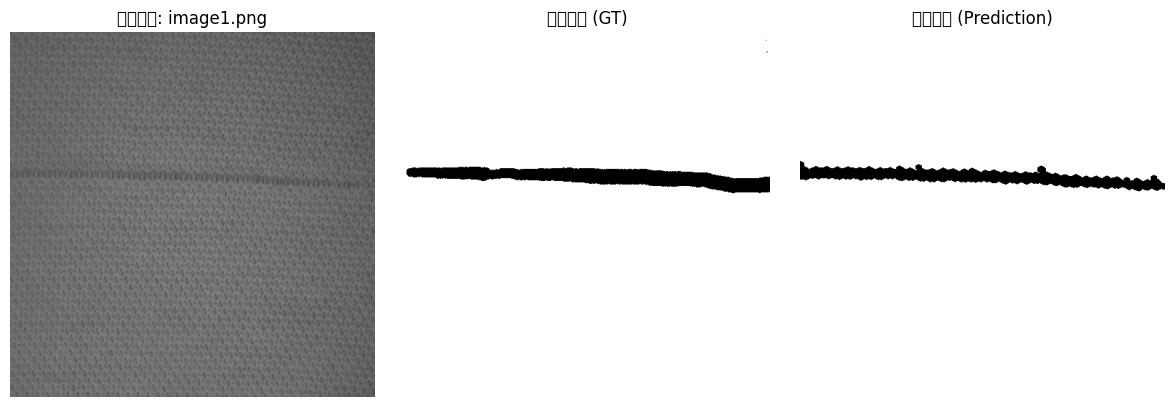

Accuracy:  0.9910
Precision: 0.9200
Recall:    0.8242
TP=7861, TN=251922, FP=684, FN=1677

Processing image2.png ...


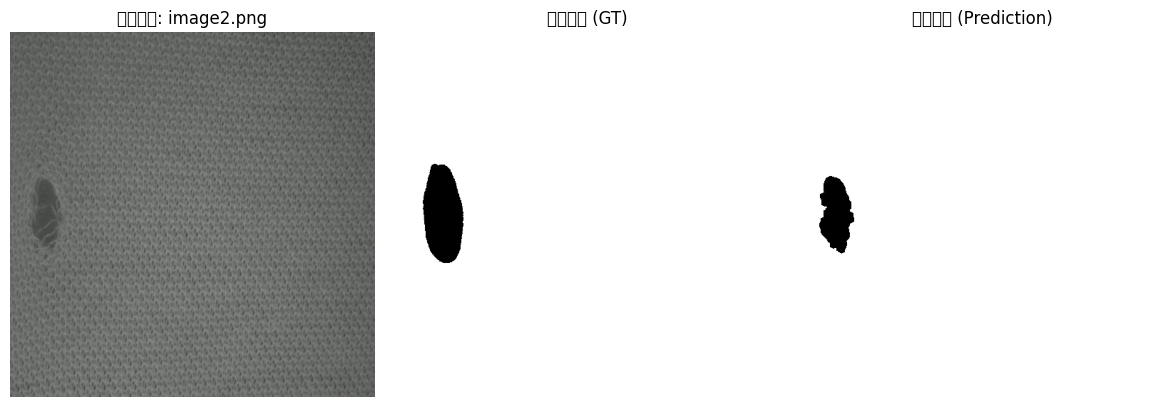

Accuracy:  0.9904
Precision: 0.9989
Recall:    0.5884
TP=3602, TN=256018, FP=4, FN=2520

=== 偵測結果摘要 ===
image1.png: Acc=0.9910, Prec=0.9200, Rec=0.8242
image2.png: Acc=0.9904, Prec=0.9989, Rec=0.5884


In [14]:
# 處理 texture test images 並直接顯示結果（Original / GT / Prediction）
base_dir = Path('.')
test_dir = base_dir / 'texture test images'

# 尋找影像檔案（排除 GT 相關檔案）
image_files = [p for p in test_dir.glob('*') if p.suffix.lower() in ['.png','.jpg','.jpeg','.bmp']]

# 試圖配對影像與 GT：GT 檔案需包含 'gt'、'ans' 或 'mask' 在名稱中
pairs = []
for p in image_files:
    name = p.name.lower()
    if 'gt' in name or 'ans' in name or 'mask' in name or 'truth' in name:
        continue
    candidates = list(test_dir.glob(p.stem + '*'))
    gt = None
    for c in candidates:
        lname = c.name.lower()
        if c == p:
            continue
        if 'gt' in lname or 'ans' in lname or 'mask' in lname or 'truth' in lname:
            gt = c
            break
    if gt is None:
        for suf in ['_gt','_ans','_mask']:
            cand = test_dir / (p.stem + suf + p.suffix)
            if cand.exists():
                gt = cand
                break
    pairs.append((p, gt))

# 偵測參數（可依需要調整）
params = {
    'background_kernel': 101,
    'alpha': 1.25,
    'min_size': 1000,
    'opening_size': 5,
    'dilation_size': 5
}

# 處理每張測試影像並直接顯示結果
metrics_results = {}
for img_path, gt_path in pairs:
    print(f'Processing {img_path.name} ...')
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 分離用於偵測的參數（排除用於後處理的 dilation_size）
    dparams = dict(params)
    dparams.pop('dilation_size', None)
    pred_mask = detect_defects_gray(gray, debug=False, **dparams)
    
    # 後處理：膨脹預測區域以更接近 GT
    pred_mask_pp = postprocess_mask(pred_mask, dilation_size=params.get('dilation_size', 5))
    
    # 轉換為 RGB 顯示
    test_img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 讀取 GT（若存在）
    gt_img = None
    metrics = None
    if gt_path and gt_path.exists():
        gt_img = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
        _, gt_bin = cv2.threshold(gt_img, 128, 255, cv2.THRESH_BINARY)
        metrics = compute_metrics(gt_bin, pred_mask_pp)
        metrics_results[img_path.name] = metrics
    
    # 直接顯示結果：Original / GT / Prediction
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    axes[0].imshow(test_img_rgb)
    axes[0].set_title(f'原始影像: {img_path.name}')
    axes[0].axis('off')
    
    if gt_img is not None:
        axes[1].imshow(gt_img, cmap='gray')
    else:
        axes[1].imshow(np.zeros_like(pred_mask_pp), cmap='gray')
    axes[1].set_title('標準答案 (GT)')
    axes[1].axis('off')
    
    axes[2].imshow(pred_mask_pp, cmap='gray')
    axes[2].set_title('偵測結果 (Prediction)')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()
    
    # 顯示評估指標（若有 GT）
    if metrics is not None:
        print(f'Accuracy:  {metrics["accuracy"]:.4f}')
        print(f'Precision: {metrics["precision"]:.4f}')
        print(f'Recall:    {metrics["recall"]:.4f}')
        print(f'TP={metrics["tp"]}, TN={metrics["tn"]}, FP={metrics["fp"]}, FN={metrics["fn"]}')
        print()

# 摘要
if metrics_results:
    print('=== 偵測結果摘要 ===')
    for k, v in metrics_results.items():
        print(f'{k}: Acc={v["accuracy"]:.4f}, Prec={v["precision"]:.4f}, Rec={v["recall"]:.4f}')

In [17]:
def extract_frames(video_path, output_folder, frames_per_second=30):
    # 確保輸出資料夾存在
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # 1. 開啟影片
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("無法開啟影片！")
        return

    fps = cap.get(cv2.CAP_PROP_FPS) # 獲取原始影片 FPS
    frame_count = 0
    saved_count = 0

    # 2. 讀取影片幀
    while(cap.isOpened()):
        ret, frame = cap.read()
        if ret:
            # 判斷是否需要儲存 (例如，每秒擷取5張)
            if frame_count % int(fps / frames_per_second) == 0:
                # 3. 儲存圖片
                # 使用格式化字串確保圖片名稱按順序排列
                filename = os.path.join(output_folder, f"frame_{saved_count:06d}.png")
                cv2.imwrite(filename, frame)
                saved_count += 1
                # print(f"已儲存: {filename}") # 可取消註解查看進度
            frame_count += 1
            # cv2.waitKey(1) # 如果要即時顯示畫面可開啟
        else:
            break # 影片結束

    # 4. 釋放資源
    cap.release()
    print(f"處理完成！共儲存 {saved_count} 張圖片到 {output_folder}")

# --- 使用範例 ---
video_file = 'texture_video.avi'  # 替換成你的影片路徑
output_dir = 'output_frames'   # 儲存圖片的資料夾

extract_frames(video_file, output_dir, frames_per_second=5)


處理完成！共儲存 907 張圖片到 output_frames
